In [9]:
import os
import random
import xml.etree.ElementTree as ET
from collections import Counter

import albumentations as A
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
import torchvision.ops as ops
from albumentations.pytorch import ToTensorV2
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from tqdm import tqdm

In [10]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_EPOCHS = 15
BATCH_SIZE = 4
LR = 0.0005

train_path = r"btl/data/train"
valid_path = r"btl/data/valid"
test_path = r"btl/data/test"    

In [12]:

# Albumentations transform: bien doi anh va bbox cung luc.
# Bbox dang Pascal VOC: [xmin, ymin, xmax, ymax].
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, border_mode=0, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.ToFloat(max_value=255.0),
    ToTensorV2(),
], bbox_params=A.BboxParams(
    format='pascal_voc',
    label_fields=['labels'],
    min_visibility=0.2
))

test_transform = A.Compose([
    A.NoOp(p=1.0),
    A.ToFloat(max_value=255.0),
    ToTensorV2(),
], bbox_params=A.BboxParams(
    format='pascal_voc',
    label_fields=['labels']
))

In [13]:
class SkinCancerVOCDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # Lay danh sach anh co file XML cung ten.
        self.image_paths = []
        self.xml_paths = []
        for fname in sorted(os.listdir(root_dir)):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            xml_name = os.path.splitext(fname)[0] + '.xml'
            xml_path = os.path.join(root_dir, xml_name)
            if os.path.exists(xml_path):
                self.image_paths.append(os.path.join(root_dir, fname))
                self.xml_paths.append(xml_path)

        # Tao mapping class -> id. Id 0 duoc Faster R-CNN dung cho background.
        class_names = set()
        for xml_path in self.xml_paths:
            tree = ET.parse(xml_path)
            for obj in tree.getroot().iter('object'):
                class_names.add(obj.find('name').text.strip())

        self.class_to_idx = {name: idx + 1 for idx, name in enumerate(sorted(class_names))}
        print(f'[Dataset] Found {len(self)} images | {len(self.class_to_idx)} classes: {self.class_to_idx}')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Doc anh.
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img_w, img_h = img.size

        # 2. Doc bbox va label tu file XML.
        boxes, labels = [], []
        tree = ET.parse(self.xml_paths[idx])
        root = tree.getroot()

        size_node = root.find('size')
        if size_node is not None:
            xml_w = float(size_node.find('width').text)
            xml_h = float(size_node.find('height').text)
        else:
            xml_w, xml_h = float(img_w), float(img_h)

        for obj in root.iter('object'):
            label_name = obj.find('name').text.strip()
            if label_name not in self.class_to_idx:
                continue

            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)

            # Gioi han bbox trong kich thuoc anh de tranh toa do vuot bien.
            xmin = max(0.0, min(xmin, xml_w))
            ymin = max(0.0, min(ymin, xml_h))
            xmax = max(0.0, min(xmax, xml_w))
            ymax = max(0.0, min(ymax, xml_h))

            # Bo qua bbox khong hop le.
            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.class_to_idx[label_name])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        # 3. Albumentations bien doi anh va bbox cung luc.
        if self.transform:
            transformed = self.transform(
                image=np.array(img),
                bboxes=boxes.tolist(),
                labels=labels.tolist()
            )
            img = transformed['image']
            boxes = torch.as_tensor(transformed['bboxes'], dtype=torch.float32)
            labels = torch.as_tensor(transformed['labels'], dtype=torch.int64)

            # Neu augmentation lam mat het bbox, giu dung shape rong (0, 4).
            if boxes.numel() == 0 or boxes.ndim == 1:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros((0,), dtype=torch.int64)
        else:
            img = T.ToTensor()(img)

        # 4. Tao target theo format Faster R-CNN.
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) if boxes.numel() > 0 else torch.zeros((0,), dtype=torch.float32)
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)
        image_id = torch.tensor([idx])

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': image_id,
            'area': area,
            'iscrowd': iscrowd
        }

        return img, target

In [14]:
train_dataset = SkinCancerVOCDataset(train_path, transform=train_transform)
valid_dataset = SkinCancerVOCDataset(valid_path, transform=test_transform)
test_dataset  = SkinCancerVOCDataset(test_path,  transform=test_transform)

def get_image_classes(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    return [obj.find('name').text.strip() for obj in root.iter('object')]

# Tinh trong so lay mau de giam imbalance tren train set.
# Dung 1/sqrt(count) de can bang mem, tranh lap lai class hiem qua nhieu.
image_classes = [get_image_classes(xml_path) for xml_path in train_dataset.xml_paths]
primary_classes = [classes[0] if len(classes) > 0 else '__empty__' for classes in image_classes]
class_counts = Counter(primary_classes)
class_weights = {cls: 1.0 / np.sqrt(count) for cls, count in class_counts.items()}
sample_weights = torch.as_tensor(
    [class_weights[cls] for cls in primary_classes],
    dtype=torch.double
)

train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print('Train class counts:', dict(class_counts))
print('Using WeightedRandomSampler for train_loader')

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    collate_fn=collate_fn,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
)

[Dataset] Found 3393 images | 9 classes: {'actinic keratosis': 1, 'basal cell carcinoma': 2, 'dermatofibroma': 3, 'melanoma': 4, 'nevus': 5, 'pigmented benign keratosis': 6, 'seborrheic keratosis': 7, 'squamous cell carcinoma': 8, 'vascular lesion': 9}
[Dataset] Found 420 images | 9 classes: {'actinic keratosis': 1, 'basal cell carcinoma': 2, 'dermatofibroma': 3, 'melanoma': 4, 'nevus': 5, 'pigmented benign keratosis': 6, 'seborrheic keratosis': 7, 'squamous cell carcinoma': 8, 'vascular lesion': 9}
[Dataset] Found 210 images | 9 classes: {'actinic keratosis': 1, 'basal cell carcinoma': 2, 'dermatofibroma': 3, 'melanoma': 4, 'nevus': 5, 'pigmented benign keratosis': 6, 'seborrheic keratosis': 7, 'squamous cell carcinoma': 8, 'vascular lesion': 9}
Train class counts: {'nevus': 425, 'melanoma': 529, 'seborrheic keratosis': 122, 'pigmented benign keratosis': 957, 'vascular lesion': 226, 'basal cell carcinoma': 513, 'squamous cell carcinoma': 298, 'dermatofibroma': 131, 'actinic keratosis'

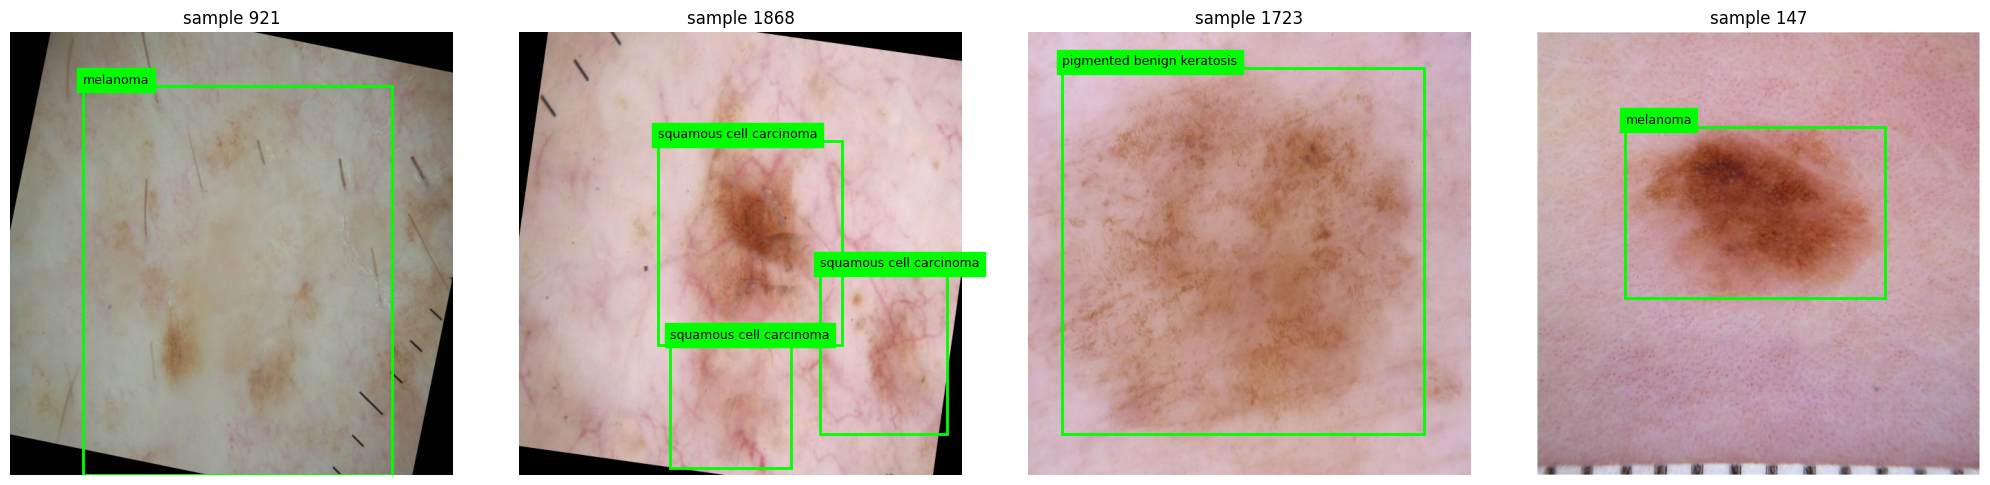

In [15]:
def show_augmented_samples(dataset, idx_to_class=None, num_samples=4):
    # Ve mot vai anh sau augmentation de kiem tra bbox co dung khong.
    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
    if num_samples == 1:
        axes = [axes]

    # Lay ngau nhien mot vai sample trong dataset train.
    for ax, sample_idx in zip(axes, random.sample(range(len(dataset)), num_samples)):
        image, target = dataset[sample_idx]

        # Doi tensor (C, H, W) thanh anh (H, W, C) de matplotlib hien thi.
        image_np = image.permute(1, 2, 0).cpu().numpy()
        image_np = np.clip(image_np, 0, 1)

        ax.imshow(image_np)

        # Ve tung bbox va ten class len anh.
        for box, label in zip(target['boxes'], target['labels']):
            xmin, ymin, xmax, ymax = box.cpu().numpy()
            rect = patches.Rectangle(
                (xmin, ymin), xmax - xmin, ymax - ymin,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)

            class_name = idx_to_class.get(label.item(), str(label.item())) if idx_to_class else str(label.item())
            ax.text(
                xmin, max(ymin - 4, 0), class_name,
                color='black', fontsize=9, backgroundcolor='lime'
            )

        ax.set_title(f'sample {sample_idx}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Doi id class ve ten class de hien thi tren anh.
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
show_augmented_samples(train_dataset, idx_to_class, num_samples=4)

In [ ]:
num_classes = len(train_dataset.class_to_idx) + 1  # + background
print(f'Number of classes: {num_classes}')

model = fasterrcnn_resnet50_fpn(weights='DEFAULT')

# Thay head phan loai cho dung so class cua dataset.
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

# Dong bang backbone de train nhanh va tiet kiem VRAM.
for param in model.backbone.parameters():
    param.requires_grad = False

model.to(DEVICE)
print(model)

Number of classes: 10
FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
 

In [17]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total parameters     : {total_params:,}")
    print(f"Trainable parameters : {trainable_params:,}")
    print(f"Frozen parameters    : {total_params - trainable_params:,}")

count_parameters(model)

Total parameters     : 41,340,161
Trainable parameters : 14,540,865
Frozen parameters    : 26,799,296


In [18]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(params,
                            lr=LR, 
                            weight_decay=0.003)

In [19]:
def move_targets_to_device(targets, device):
    return [{k: v.to(device) for k, v in t.items()} for t in targets]

def prepare_map_targets(targets):
    return [
        {'boxes': t['boxes'].detach().cpu(), 'labels': t['labels'].detach().cpu()}
        for t in targets
    ]

def prepare_map_predictions(outputs):
    return [
        {
            'boxes': out['boxes'].detach().cpu(),
            'scores': out['scores'].detach().cpu(),
            'labels': out['labels'].detach().cpu(),
        }
        for out in outputs
    ]

print(f'Training on device: {DEVICE}')
train_losses = []
val_losses = []
val_maps = []
val_map50s = []
val_map75s = []

best_map = -1.0
os.makedirs('checkpoints', exist_ok=True)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]')

    for images, targets in train_bar:
        images = [img.to(DEVICE) for img in images]
        targets = move_targets_to_device(targets, DEVICE)

        loss_dict = model(images, targets)
        losses = torch.stack(list(loss_dict.values())).sum()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        train_bar.set_postfix(loss=losses.item())

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Tinh validation loss: de model o train mode nhung khong update gradient.
    val_loss = 0
    model.train()
    with torch.no_grad():
        for images, targets in tqdm(valid_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val Loss]'):
            images = [img.to(DEVICE) for img in images]
            targets = move_targets_to_device(targets, DEVICE)

            loss_dict = model(images, targets)
            v_losses = torch.stack(list(loss_dict.values())).sum()
            val_loss += v_losses.item()

    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)

    # Tinh mAP tren valid set: de model eval va lay prediction.
    map_metric = MeanAveragePrecision(
        box_format='xyxy',
        iou_type='bbox',
        backend='faster_coco_eval'
    )

    model.eval()
    with torch.no_grad():
        for images, targets in tqdm(valid_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [mAP]'):
            images = [img.to(DEVICE) for img in images]
            outputs = model(images)

            preds = prepare_map_predictions(outputs)
            gts = prepare_map_targets(targets)
            map_metric.update(preds, gts)

    map_result = map_metric.compute()
    val_map = map_result['map'].item()
    val_map50 = map_result['map_50'].item()
    val_map75 = map_result['map_75'].item()

    val_maps.append(val_map)
    val_map50s.append(val_map50)
    val_map75s.append(val_map75)

    print(
        f'\n=> Epoch [{epoch+1}/{NUM_EPOCHS}] | '
        f'Train Loss: {avg_train_loss:.4f} | '
        f'Val Loss: {avg_val_loss:.4f} | '
        f'mAP: {val_map:.4f} | '
        f'mAP@50: {val_map50:.4f} | '
        f'mAP@75: {val_map75:.4f}'
    )

    torch.save(model.state_dict(), 'checkpoints/last.pth')

    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), 'checkpoints/best.pth')
        print('--- Saved BEST model by validation mAP ---')

Training on device: cuda


Epoch 1/15 [mAP]: 100%|██████████| 420/420 [00:41<00:00, 10.05it/s]



=> Epoch [1/15] | Train Loss: 0.2529 | Val Loss: 0.2282 | mAP: 0.1306 | mAP@50: 0.2890 | mAP@75: 0.0914
--- Saved BEST model by validation mAP ---


Epoch 2/15 [mAP]: 100%|██████████| 420/420 [00:41<00:00, 10.01it/s]



=> Epoch [2/15] | Train Loss: 0.2106 | Val Loss: 0.2289 | mAP: 0.1348 | mAP@50: 0.3204 | mAP@75: 0.0768
--- Saved BEST model by validation mAP ---


...


=> Epoch [9/15] | Train Loss: 0.2659 | Val Loss: 0.2413 | mAP: 0.2080 | mAP@50: 0.4172 | mAP@75: 0.1713
--- Saved BEST model by validation mAP ---


Epoch 10/15 [mAP]: 100%|██████████| 420/420 [00:45<00:00,  9.20it/s]



=> Epoch [10/15] | Train Loss: 0.2054 | Val Loss: 0.2568 | mAP: 0.2057 | mAP@50: 0.4274 | mAP@75: 0.1632


Epoch 11/15 [Train]:  85%|████████▌ | 723/849 [05:21<00:56,  2.25it/s, loss=0.246] 


KeyboardInterrupt: 

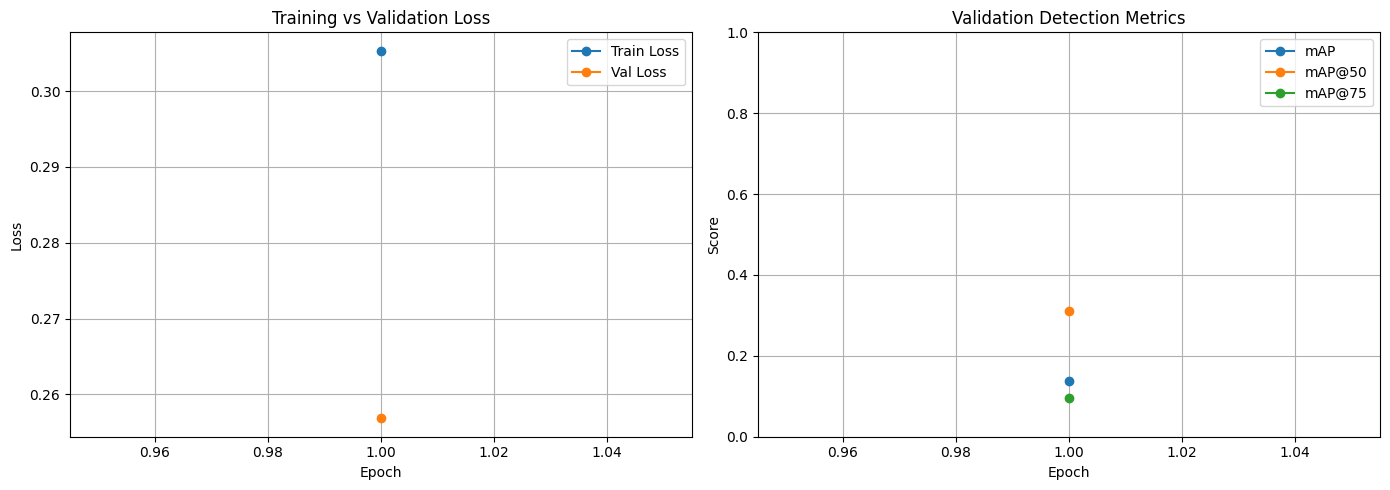

In [ ]:
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bieu do loss: theo doi model hoc co on dinh khong.
axes[0].plot(epochs, train_losses, marker='o', label='Train Loss')
axes[0].plot(epochs, val_losses, marker='o', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Bieu do mAP: danh gia chat luong bbox va class tren valid set.
axes[1].plot(epochs, val_maps, marker='o', label='mAP')
axes[1].plot(epochs, val_map50s, marker='o', label='mAP@50')
axes[1].plot(epochs, val_map75s, marker='o', label='mAP@75')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Detection Metrics')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')
plt.show()

# Test

In [ ]:
def visualize_prediction(image, output, idx_to_class=None, conf_threshold=0.5, iou_threshold=0.3):
    # Lay ket qua du doan ve CPU de xu ly va ve anh.
    boxes = output['boxes'].cpu()
    labels = output['labels'].cpu()
    scores = output['scores'].cpu()

    # NMS giup loai bo cac bbox trung lap qua nhieu.
    keep_idx = ops.nms(boxes, scores, iou_threshold)
    boxes = boxes[keep_idx]
    labels = labels[keep_idx]
    scores = scores[keep_idx]

    image_np = image.permute(1, 2, 0).cpu().numpy()
    image_np = np.clip(image_np, 0, 1)

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image_np)

    # Chi ve nhung bbox co score du cao.
    for box, label, score in zip(boxes, labels, scores):
        if score < conf_threshold:
            continue

        xmin, ymin, xmax, ymax = box.numpy()
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        class_name = idx_to_class[label.item()] if idx_to_class else str(label.item())
        ax.text(
            xmin, max(ymin - 5, 0), f'{class_name}: {score:.2f}',
            color='red', fontsize=10, backgroundcolor='white'
        )

    plt.axis('off')
    plt.show()

In [ ]:
def predict_image(image_path, model, device, idx_to_class=None, score_thresh=0.5):
    transform = T.Compose([T.ToTensor()])
    
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model([image_tensor])[0]
    
    return image_tensor.cpu(), output

In [ ]:
image_path = r"btl/data\test\ISIC_0000021_downsampled_jpg.rf.8c49330bcfaf4afb3fd31b5b5f79ec11.jpg"

In [ ]:
# mapping label
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

image_tensor, output = predict_image(image_path, model, DEVICE)

visualize_prediction(image_tensor, output, idx_to_class)

FileNotFoundError: [Errno 2] No such file or directory: 'btl/data\\test\\ISIC_0000021_downsampled_jpg.rf.8c49330bcfaf4afb3fd31b5b5f79ec11.jpg'